# Notebook to plot Temperature Anomaly On Breakup Day
- Jeamilett Martinez, Kristina Black, Alice DuVivier
- April 2026

## Import the python modules we'll need

In [77]:
import xarray as xr
import pandas as pd
import numpy as np
import glob
from scipy.stats import ttest_1samp
from scipy.stats import percentileofscore
from scipy.stats import linregress
import matplotlib.pyplot as plt
import netCDF4 as nc
import os
import re
import calendar
import cartopy
import cartopy.crs as ccrs
import geopandas as gpd
from cartopy.feature import ShapelyFeature
from cartopy import crs as ccrs

# Load grid information needed for plotting

In [2]:
# Load the 2d lat/lon for the Alaska domain
file_path = '/glade/campaign/univ/ucub0089/nna_runs/NNA.4km.hERA5.1989.003/atm/hist/'
file_in = 'NNA.4km.hERA5.1989.003.wrf.hda.1989-06.nc'

# Load dataset (assuming this has correct lat/lon grids)
ds_grid = xr.open_mfdataset(file_path + file_in, decode_times=False)
lat_2d = ds_grid.XLAT.isel(Time=0)
lon_2d = ds_grid.XLONG.isel(Time=0)
#lat_2d.plot()
#lon_2d.plot()

In [3]:
# convert all longitudes to a 0-360 grid if needed
if lon_2d.max() > 180:
    lon_pf += 360

In [4]:
# Load river basin shapefile for the Arctic
hb = gpd.read_file("/glade/u/home/klblack/SOARS_25/hybas_ar_lev03_v1c.shp")
print(hb.columns)

# Rough bounding box for Yukon River Basin (in degrees)
yukon = hb[hb['PFAF_ID'] == 812]
yukon = yukon.to_crs("EPSG:4326")

# Reproject to match the map projection
boundary_proj = yukon.to_crs(ccrs.NorthPolarStereo(central_longitude=-150.0).proj4_init)

Index(['HYBAS_ID', 'NEXT_DOWN', 'NEXT_SINK', 'MAIN_BAS', 'DIST_SINK',
       'DIST_MAIN', 'SUB_AREA', 'UP_AREA', 'PFAF_ID', 'ENDO', 'COAST', 'ORDER',
       'SORT', 'geometry'],
      dtype='object')


# Load ice breakup date information
- Use this to figure out which files to load with temperature

In [5]:
# Load ice breakup data for all communities
df = pd.read_csv("Phenology.csv")
df['Date'] = pd.to_datetime(df['Date'])

In [6]:
# Get ice breakup data for Eagle
print('Eagle')
comid = 81014736
df_breakup = df[(df['COMID'] == comid) & (df['Event'] == 'breakup') ]['Date'].values

# convert to day of year and find max and min to get dates
doy_breakup = pd.to_datetime(df_breakup).dayofyear

print('Earliest breakup') 
print(doy_breakup.min())
print('Latest breakup') 
print(doy_breakup.max())

Eagle
Earliest breakup
116
Latest breakup
133


These correspond to April 26 (DOY = 116) and May 13 (DOY = 133)

In [7]:
# Get ice breakup data for Galena
print('Galena')
comid = 81014218
df_breakup = df[(df['COMID'] == comid) & (df['Event'] == 'breakup') ]['Date'].values

# convert to day of year and find max and min to get dates
doy_breakup = pd.to_datetime(df_breakup).dayofyear

print('Earliest breakup') 
print(doy_breakup.min())
print('Latest breakup') 
print(doy_breakup.max())

Galena
Earliest breakup
121
Latest breakup
144


These correspond to May 1 (DOY = 121) and May 24 (DOY = 144)

# Load daily NetCDF files with temperature data
- These are from regional high resolution (4km) WRF-Hydro simulations over the historical period
- Load ONLY April and May data to help with daily data loading time. We don't need other months information anyway

In [8]:
# Path to 4km resolution Alaska files (coupled WRF-CTSM simulation)
file_path = '/glade/campaign/univ/ucub0089/nna_runs/NNA.4km.hERA5.1989.003/lnd/hist'

# Open a sample file to inspect its variables
sample_file = os.path.join(file_path, 'NNA.4km.hERA5.1989.003.clm2.h2.2021-09-30.nc')
with nc.Dataset(sample_file, 'r') as ds:
    print(ds.variables.keys())


dict_keys(['levgrnd', 'levsoi', 'levlak', 'levdcmp', 'time', 'mcdate', 'mcsec', 'mdcur', 'mscur', 'nstep', 'time_bounds', 'date_written', 'time_written', 'lon', 'lat', 'area', 'landfrac', 'landmask', 'pftmask', 'nbedrock', 'ALBD', 'ALT', 'ATM_TOPO', 'DSL', 'EFLX_GNET', 'EFLX_GRND_LAKE', 'EFLX_LH_TOT', 'FCEV', 'FCTR', 'FGEV', 'FGR', 'FGR12', 'FH2OSFC', 'FIRA', 'FIRE', 'FLDS', 'FSA', 'FSD24', 'FSDS', 'FSH', 'FSH_PRECIP_CONVERSION', 'FSH_RUNOFF_ICE_TO_LIQ', 'FSI24', 'FSM', 'FSM_ICE', 'FSNO', 'FSR', 'H2OCAN', 'H2OSFC', 'H2OSNO', 'H2OSOI', 'LIQCAN', 'LWup', 'PBOT', 'Q2M', 'QBOT', 'QDIRECT_THROUGHFALL', 'QDIRECT_THROUGHFALL_SNOW', 'QDRAI', 'QDRAI_PERCH', 'QDRAI_XS', 'QDRIP', 'QDRIP_SNOW', 'QFLOOD', 'QFLX_EVAP_TOT', 'QFLX_LIQDEW_TO_TOP_LAYER', 'QFLX_LIQEVAP_FROM_TOP_LAYER', 'QFLX_SNOW_DRAIN', 'QFLX_SNOW_DRAIN_ICE', 'QFLX_SOLIDDEW_TO_TOP_LAYER', 'QFLX_SOLIDEVAP_FROM_TOP_LAYER', 'QH2OSFC', 'QINFL', 'QINTR', 'QOVER', 'QRGWL', 'QRUNOFF', 'QSNOMELT', 'QSNOUNLOAD', 'QSNO_TEMPUNLOAD', 'QSNO_WINDUNLO

In [9]:
# Get the list of NetCDF files for daily data only (each file has daily averages at one time step)
file_list = glob.glob(os.path.join(file_path, 'NNA.4km.hERA5.1989.003.clm2.h2*.nc'))

In [10]:
# Filter out files < 1991 (model spin-up period)
file_list = [f for f in file_list if 1991 <= int(re.search(r'(\d{4})-(\d{2})-(\d{2})', f).group(1)) <= 2021]

In [11]:
# Filter out files NOT April or May
file_list = [f for f in file_list if 4 <= int(re.search(r'(\d{4})-(\d{2})-(\d{2})', f).group(2)) <= 5]

In [12]:
# Extract year-month-day from each file name
file_info = []
for f in file_list:
    # Match full date: yyyy-mm-dd
    match = re.search(r'(\d{4})-(\d{2})-(\d{2})', f)
    if match:
        year, month, day = match.groups()
        file_info.append((int(year), int(month), int(day), f))

# Sort files by full date
file_info.sort()

In [13]:
# load in the dataset using xarray
ds = xr.open_mfdataset(file_list, decode_times=True)

In [14]:
# check the time indices - starts in 1991 and ends in 2021
print(ds.time.dt.year)
print(ds.time.dt.month)
print(ds.time.dt.day)

<xarray.DataArray 'year' (time: 1890)> Size: 15kB
array([1991, 1991, 1991, ..., 2021, 2021, 2021])
Coordinates:
  * time     (time) datetime64[ns] 15kB 1991-04-02 1991-04-03 ... 2021-06-01
Attributes:
    long_name:  time
    bounds:     time_bounds
<xarray.DataArray 'month' (time: 1890)> Size: 15kB
array([4, 4, 4, ..., 5, 5, 6])
Coordinates:
  * time     (time) datetime64[ns] 15kB 1991-04-02 1991-04-03 ... 2021-06-01
Attributes:
    long_name:  time
    bounds:     time_bounds
<xarray.DataArray 'day' (time: 1890)> Size: 15kB
array([ 2,  3,  4, ..., 30, 31,  1])
Coordinates:
  * time     (time) datetime64[ns] 15kB 1991-04-02 1991-04-03 ... 2021-06-01
Attributes:
    long_name:  time
    bounds:     time_bounds


In [15]:
# looks like the dates are shifted by a day (it writes the time at the end of the day, not the middle of the day)
# compute time mean to get correct day and set time to middle of the day
ds['time']= ds.time_bounds.compute().mean(dim='hist_interval')

In [16]:
# now check the time indices
print(ds.time.dt.year)
print(ds.time.dt.month)
print(ds.time.dt.day)

<xarray.DataArray 'year' (time: 1890)> Size: 15kB
array([1991, 1991, 1991, ..., 2021, 2021, 2021])
Coordinates:
  * time     (time) datetime64[ns] 15kB 1991-04-01T12:00:00 ... 2021-05-31T12...
<xarray.DataArray 'month' (time: 1890)> Size: 15kB
array([4, 4, 4, ..., 5, 5, 5])
Coordinates:
  * time     (time) datetime64[ns] 15kB 1991-04-01T12:00:00 ... 2021-05-31T12...
<xarray.DataArray 'day' (time: 1890)> Size: 15kB
array([ 1,  2,  3, ..., 29, 30, 31])
Coordinates:
  * time     (time) datetime64[ns] 15kB 1991-04-01T12:00:00 ... 2021-05-31T12...


In [17]:
# get a list of all years
years_all = ds.coords['time.year'][(ds.coords['time.month']==4)]
nyears = len(years_all)

In [18]:
# Extract daily max temperature
temp_daily = ds.TREFMXAV  # shape: (time, lat, lon)

# Define the year range
years = np.arange(1991, 2022)

# Calculate temperature and anomalies on breakup day for flood years
- Calculate and plot anomaly over whole Yukon Basin
- Calculate and plot box and whisker of temperature change rate at the impacted villages

## 2009 - Flood in Eagle

### Find grid point closest to village

In [108]:
# Coordinates for village
lat_village = 64.786022 
lon_village = -141.199917
village_name = 'Eagle'
comid = 81014736
yy = 2009

In [109]:
# First, find the index of the grid point nearest a specific lat/lon.   
abslat = np.abs(lat_2d - lat_village)
abslon = np.abs(lon_2d - lon_village)
c = np.maximum(abslon, abslat)

# find the smallest values
([xloc], [yloc]) = np.where(c == np.min(c))

# print index values
print(xloc,yloc)

372 552


In [110]:
print(lat_2d[xloc,yloc].values)
print(lon_2d[xloc,yloc].values)

64.79025
-141.18173


### Find temperature data for ice breakup date in this event

In [111]:
# Get breakup date for Eagle in 2009
village_breakup = df[
    (df['COMID'] == comid) & 
    (df['Event'] == 'breakup') & 
    (df['Year'] == yy)
]['Date'].values[0]
village_breakup = np.datetime64(pd.to_datetime(village_breakup).date())  # strip time

print(village_breakup)

2009-04-30


In [112]:
# Convert temp_daily time to date-only format to match
temp_dates = temp_daily['time'].values.astype('datetime64[D]')
matching_idx = np.where(temp_dates == village_breakup)[0]

if len(matching_idx) == 0:
    raise ValueError("Breakup date not found in temperature time series!")
    
# Extract temperature on that day
breakup_temp = temp_daily.isel(time=matching_idx[0]) - 273.15  # Convert from K to °C

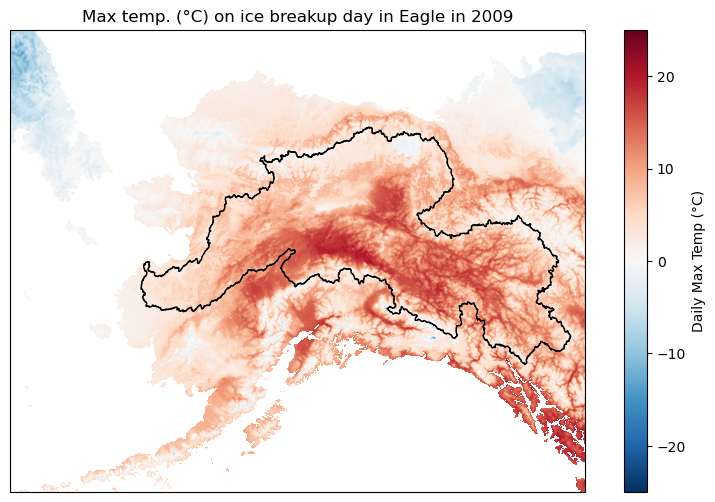

In [113]:
fig = plt.figure(figsize=(10,6))
cmap = plt.colormaps['RdBu_r']

# Set symmetric color scale around 0
vmax = np.nanmax(np.abs(breakup_temp))
vmin = -vmax

ax = plt.subplot(1,1,1, projection=ccrs.NorthPolarStereo(central_longitude=-150.0))
ax.set_extent([-170, -132, 55, 72], crs=ccrs.PlateCarree())

cs0 = ax.pcolormesh(lon_2d, lat_2d,
                    breakup_temp,
                    cmap=cmap, vmin=-25, vmax=25,
                    shading='auto',
                    transform=ccrs.PlateCarree())

cbar = fig.colorbar(cs0, ax=ax, label='Daily Max Temp (°C)')
ax.set_title('Max temp. (°C) on ice breakup day in ' + village_name + ' in ' +str(yy))

# Add shapefile boundary
ax.add_geometries(yukon.geometry, crs=ccrs.PlateCarree(),
                  edgecolor='black', facecolor='none', linewidth=1)

plt.show()

### Find this year's temperature anomaly on breakup day

In [114]:
# Get all breakup dates for village
village_breakups = df[(df['COMID'] == comid) & (df['Event'] == 'breakup')].copy()
village_breakups['Date'] = pd.to_datetime(village_breakups['Date']).dt.date

# Separate flood year and 1995–2005
village_date = village_breakups[village_breakups['Year'] == yy]['Date'].values[0]

# Filter years 1995–2005 for historical average
village_hist = village_breakups[(village_breakups['Year'] >= 1995) & (village_breakups['Year'] <= 2005)]
village_hist_dates = village_hist['Date'].values
print(village_hist_dates)

[datetime.date(1995, 4, 29) datetime.date(1996, 5, 1)
 datetime.date(1997, 5, 1) datetime.date(1998, 4, 26)
 datetime.date(1999, 5, 1) datetime.date(2000, 5, 1)
 datetime.date(2001, 5, 2) datetime.date(2002, 5, 7)
 datetime.date(2003, 4, 28) datetime.date(2004, 4, 30)
 datetime.date(2005, 4, 26)]


In [115]:
# Extract temperature (across AK) for each historical breakup date:

# Assume temp_daily is already loaded and has time coordinate
temp_dates = temp_daily['time'].values.astype('datetime64[D]')
hist_temps = []

for date in village_hist_dates:
    date_np = np.datetime64(date)
    match_idx = np.where(temp_dates == date_np)[0]
    if len(match_idx) == 0:
        continue  # skip missing
    temp_day = temp_daily.isel(time=match_idx[0]) - 273.15  # K to °C
    hist_temps.append(temp_day.values)

# Compute the historical mean (same shape as one temp_day)
hist_mean_temp = np.mean(np.stack(hist_temps), axis=0)

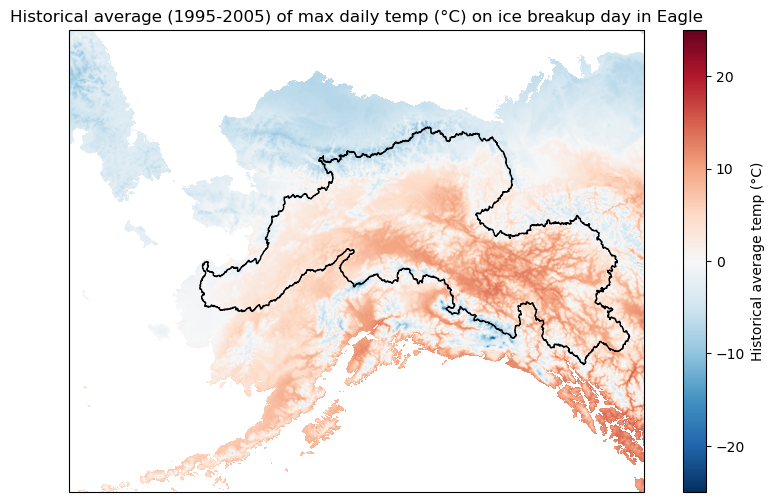

In [116]:
# plot map of the average temperature on breakup day

fig = plt.figure(figsize=(10,6))
cmap = plt.colormaps['RdBu_r']

ax = plt.subplot(1,1,1, projection=ccrs.NorthPolarStereo(central_longitude=-150.0))
ax.set_extent([-170, -132, 55, 72], crs=ccrs.PlateCarree())

cs0 = ax.pcolormesh(lon_2d, lat_2d,
                    hist_mean_temp,
                    cmap=cmap, vmin=-25, vmax=25,
                    shading='auto',
                    transform=ccrs.PlateCarree())

cbar = fig.colorbar(cs0, ax=ax, label='Historical average temp (°C)')
ax.set_title('Historical average (1995-2005) of max daily temp (°C) on ice breakup day in ' + village_name)

# Add shapefile boundary
ax.add_geometries(yukon.geometry, crs=ccrs.PlateCarree(),
                  edgecolor='black', facecolor='none', linewidth=1)

plt.show()

In [117]:
# Get flood year temperature
date_yyyy_np = np.datetime64(village_date)
match_yyyy = np.where(temp_dates == date_yyyy_np)[0][0]
temp_yyyy = temp_daily.isel(time=match_yyyy) - 273.15  # K to °C

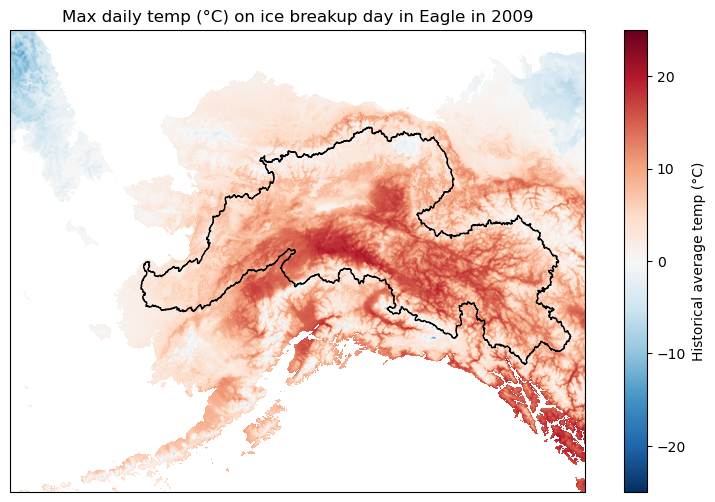

In [118]:
# plot map of temperature on breakup day in flood year

fig = plt.figure(figsize=(10,6))
cmap = plt.colormaps['RdBu_r']

ax = plt.subplot(1,1,1, projection=ccrs.NorthPolarStereo(central_longitude=-150.0))
ax.set_extent([-170, -132, 55, 72], crs=ccrs.PlateCarree())

cs0 = ax.pcolormesh(lon_2d, lat_2d,
                    temp_yyyy,
                    cmap=cmap, vmin=-25, vmax=25,
                    shading='auto',
                    transform=ccrs.PlateCarree())

cbar = fig.colorbar(cs0, ax=ax, label='Historical average temp (°C)')
ax.set_title('Max daily temp (°C) on ice breakup day in ' + village_name + ' in '+str(yy))

# Add shapefile boundary
ax.add_geometries(yukon.geometry, crs=ccrs.PlateCarree(),
                  edgecolor='black', facecolor='none', linewidth=1)

plt.show()

In [119]:
# Compute the anomaly (difference from 1995–2005 mean)
anomaly_yyyy = temp_yyyy.values - hist_mean_temp

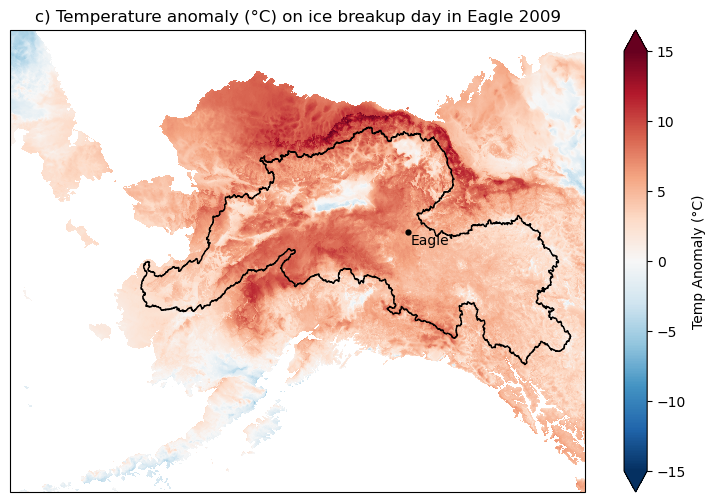

In [120]:
fig = plt.figure(figsize=(10,6))
cmap = plt.colormaps['RdBu_r']

fout = 'temperature_anomaly_on_breakup_'+str(yy)+'.png'

ax = plt.subplot(1,1,1, projection=ccrs.NorthPolarStereo(central_longitude=-150.0))
ax.set_extent([-170, -132, 55, 72], crs=ccrs.PlateCarree())

cs0 = ax.pcolormesh(lon_2d, lat_2d,
                    anomaly_yyyy,
                    cmap=cmap, vmin=-15, vmax=15,
                    shading='auto',
                    transform=ccrs.PlateCarree())

cbar = fig.colorbar(cs0, ax=ax, extend='both',label='Temp Anomaly (°C)')
ax.set_title('c) Temperature anomaly (°C) on ice breakup day in '+village_name+' '+ str(yy))

# Add shapefile boundary
ax.add_geometries(yukon.geometry, crs=ccrs.PlateCarree(),
                  edgecolor='black', facecolor='none', linewidth=1)

# Add point
ax.plot(lon_2d[xloc, yloc].values, lat_2d[xloc, yloc].values, marker='.', color='black', markersize=7, transform=ccrs.PlateCarree())
ax.text(lon_2d[xloc, yloc].values, lat_2d[xloc, yloc].values - 0.5, village_name, color='black', transform=ccrs.PlateCarree())

# save figure
plt.savefig(fout, bbox_inches="tight")
plt.show()


### Plot the distribution of values in Village 1995-2020

In [121]:
# Extract breakup dates for this village
village_breakup = df[(df['Event'] == 'breakup') & (df['COMID'] == comid)].copy()
village_breakup = village_breakup.set_index('Year')

In [122]:
# Get the time array time series
temp_series = temp_daily[:, xloc, yloc]  # shape: (time,)
time_series = temp_series['time'].values

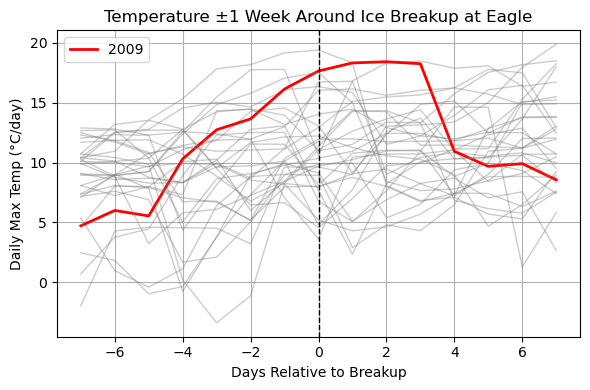

In [123]:
# Plot the raw temperatures before and after breakup at this village
days_range = np.arange(-7, 8)
hydrograph_data = {}

# Loop through breakup years 
for year, row in galena_breakup.iterrows():
    breakup_date = np.datetime64(row['Date'].date())  # strip time to match daily data

    # Get time array from temp_series and convert to date only
    temp_dates = temp_series['time'].values.astype('datetime64[D]')
    matching_idxs = np.where(temp_dates == breakup_date)[0]

    if len(matching_idxs) == 0:
        continue  # Skip if no matching date found
    center_idx = matching_idxs[0]

    # ±7 day window
    idx_range = center_idx + days_range
    if np.any(idx_range < 0) or np.any(idx_range >= len(temp_series)):
        continue

    temps = temp_series[idx_range].values - 273.15  # Convert from K to °C
    hydrograph_data[year] = temps

# Make plot
plt.figure(figsize=(6,4))
for year, slopes in hydrograph_data.items():
    color = 'red' if year == yy else 'gray'
    lw = 2 if year == yy else 1
    alpha = 1.0 if year == yy else 0.4
    label = str(year) if year == yy else None
    plt.plot(days_range, slopes, color=color, linewidth=lw, alpha=alpha, label=label)

plt.axvline(x=0, linestyle='--', color='black', linewidth=1)
plt.title('Temperature ±1 Week Around Ice Breakup at '+village_name)
plt.xlabel('Days Relative to Breakup')
plt.ylabel('Daily Max Temp (°C/day)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

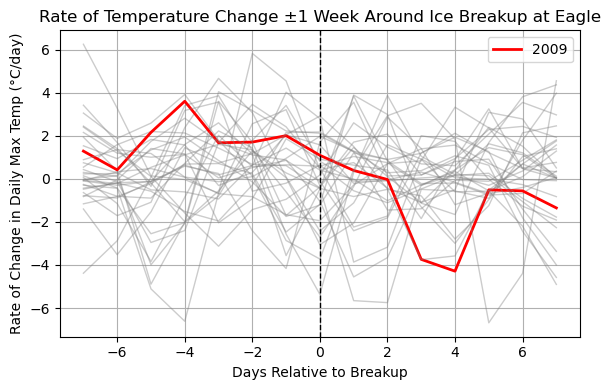

In [124]:
# Plot the rate of temperature change before and after breakup at this village
days_range = np.arange(-7, 8) # number of days before/after breakup to plot
hydrograph_slope_data = {}

for year, row in galena_breakup.iterrows():
    breakup_date = np.datetime64(row['Date'].date())  # strip time to match daily resolution

    # Get time array from temp_series, cast to date only
    temp_dates = temp_series['time'].values.astype('datetime64[D]')

    # Find the index with the same date
    matching_idxs = np.where(temp_dates == breakup_date)[0]

    if len(matching_idxs) == 0:
        continue  # Skip if no matching date found
    center_idx = matching_idxs[0]

    # Extract 15-day window (±7 days)
    idx_range = center_idx + days_range
    if np.any(idx_range < 0) or np.any(idx_range >= len(temp_series)):
        continue  # Skip if out of bounds

    temps = temp_series[idx_range].values - 273.15  # Convert from K to °C
    temp_slope = np.gradient(temps)
    hydrograph_slope_data[year] = temp_slope

# Make Plot
plt.figure(figsize=(6, 4))
for year, slopes in hydrograph_slope_data.items():
    color = 'red' if year == yy else 'gray'
    lw = 2 if year == yy else 1
    alpha = 1.0 if year == yy else 0.4
    label = str(year) if year == yy else None
    plt.plot(days_range, slopes, color=color, linewidth=lw, alpha=alpha, label=label)

plt.axvline(x=0, linestyle='--', color='black', linewidth=1)
plt.title('Rate of Temperature Change ±1 Week Around Ice Breakup at '+village_name)
plt.xlabel('Days Relative to Breakup')
plt.ylabel('Rate of Change in Daily Max Temp (°C/day)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [125]:
# Check if the flood year was significantly different rate of temperature increase compared to other years at this village

temp_slopes = {}  # key = year, value = slope

for year, temps in hydrograph_data.items():
    slope, intercept, r_value, p_value, std_err = linregress(days_range, temps)
    temp_slopes[year] = slope

# get flood year only
slope_yyyy = temp_slopes.get(yy)
other_slopes = [s for y, s in temp_slopes.items() if y != yy]

# get all slopes
slope_df = pd.DataFrame({
    'Year': list(temp_slopes.keys()),
    'Slope (°C/day)': list(temp_slopes.values())
}).sort_values('Year')

#print(slope_df)

# check statistical difference
t_stat, p_val = ttest_1samp(other_slopes, popmean=slope_yyyy)
print('p-value for '+str(yy)+' slope being different from other years:')
print(f"{p_val:.2e}")

p-value for 2009 slope being different from other years:
6.59e-02


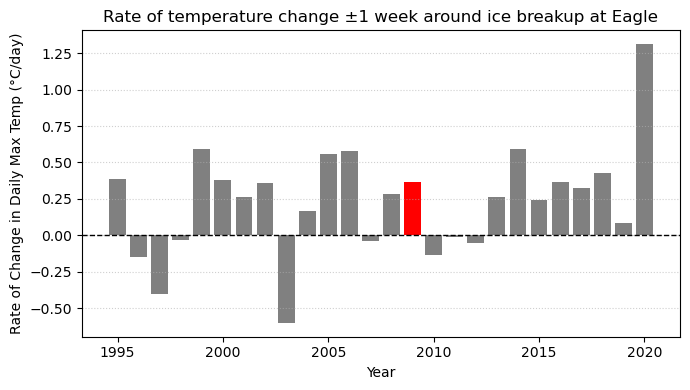

In [126]:
# Plot bar graph for all temperature rates and flood year

# Filter for 1995–2020
filtered_years = [year for year in temp_slopes if 1995 <= year <= 2020]
filtered_years.sort()
filtered_slopes = [temp_slopes[year] for year in filtered_years]
colors = ['red' if year == yy else 'gray' for year in filtered_years]

# Plot slopes
plt.figure(figsize=(7, 4))
plt.bar(filtered_years, filtered_slopes, color=colors)
plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.title('Rate of temperature change ±1 week around ice breakup at '+village_name)
plt.xlabel('Year')
plt.ylabel('Rate of Change in Daily Max Temp (°C/day)')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

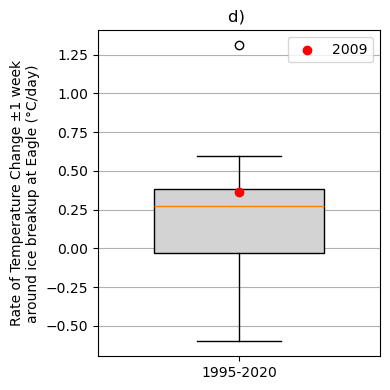

In [127]:
# Plot As Box and Whisker of April Snow Depth distribution
fout = 'temperature_rates_distribution_'+village_name+'_'+str(yy)+'.png'

plt.figure(figsize=(4, 4))
plt.boxplot(filtered_slopes, positions=[0], widths=0.6, patch_artist=True, boxprops=dict(facecolor='lightgray'))
plt.scatter([0], [slope_yyyy], color='red', label=str(yy), zorder=10)
plt.ylabel('Rate of Temperature Change ±1 week\naround ice breakup at '+village_name+' (°C/day)')
plt.title('d) ')
plt.xticks([0], ['1995-2020'])
plt.grid(True, axis='y')
plt.legend()
plt.tight_layout()
plt.savefig(fout, bbox_inches='tight')
plt.show()

## 2013 - Flood in Galena

### Find grid point closest to village

In [128]:
# Coordinates for village
lat_village = 64.740643 
lon_village = -156.885462
village_name = 'Galena'
comid = 81014218
yy = 2013

In [129]:
# First, find the index of the grid point nearest a specific lat/lon.   
abslat = np.abs(lat_2d - lat_village)
abslon = np.abs(lon_2d - lon_village)
c = np.maximum(abslon, abslat)

# find the smallest values
([xloc], [yloc]) = np.where(c == np.min(c))

# print index values
print(xloc,yloc)

351 368


In [130]:
print(lat_2d[xloc,yloc].values)
print(lon_2d[xloc,yloc].values)

64.725174
-156.90182


### Find temperature data for ice breakup date in this event

In [131]:
# Get breakup date for Eagle in 2009
village_breakup = df[
    (df['COMID'] == comid) & 
    (df['Event'] == 'breakup') & 
    (df['Year'] == yy)
]['Date'].values[0]
village_breakup = np.datetime64(pd.to_datetime(village_breakup).date())  # strip time

print(village_breakup)

2013-05-23


In [132]:
# Convert temp_daily time to date-only format to match
temp_dates = temp_daily['time'].values.astype('datetime64[D]')
matching_idx = np.where(temp_dates == village_breakup)[0]

if len(matching_idx) == 0:
    raise ValueError("Breakup date not found in temperature time series!")
    
# Extract temperature on that day
breakup_temp = temp_daily.isel(time=matching_idx[0]) - 273.15  # Convert from K to °C

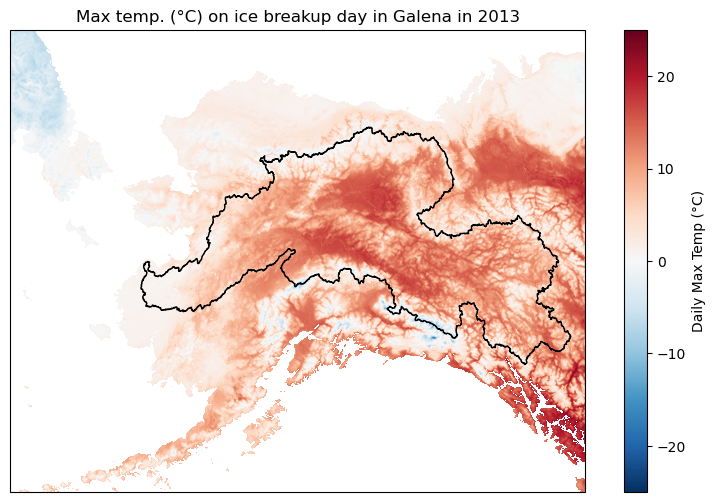

In [133]:
fig = plt.figure(figsize=(10,6))
cmap = plt.colormaps['RdBu_r']

# Set symmetric color scale around 0
vmax = np.nanmax(np.abs(breakup_temp))
vmin = -vmax

ax = plt.subplot(1,1,1, projection=ccrs.NorthPolarStereo(central_longitude=-150.0))
ax.set_extent([-170, -132, 55, 72], crs=ccrs.PlateCarree())

cs0 = ax.pcolormesh(lon_2d, lat_2d,
                    breakup_temp,
                    cmap=cmap, vmin=-25, vmax=25,
                    shading='auto',
                    transform=ccrs.PlateCarree())

cbar = fig.colorbar(cs0, ax=ax, label='Daily Max Temp (°C)')
ax.set_title('Max temp. (°C) on ice breakup day in ' + village_name + ' in ' +str(yy))

# Add shapefile boundary
ax.add_geometries(yukon.geometry, crs=ccrs.PlateCarree(),
                  edgecolor='black', facecolor='none', linewidth=1)

plt.show()

### Find this year's temperature anomaly on breakup day

In [134]:
# Get all breakup dates for village
village_breakups = df[(df['COMID'] == comid) & (df['Event'] == 'breakup')].copy()
village_breakups['Date'] = pd.to_datetime(village_breakups['Date']).dt.date

# Separate flood year and 1995–2005
village_date = village_breakups[village_breakups['Year'] == yy]['Date'].values[0]

# Filter years 1995–2005 for historical average
village_hist = village_breakups[(village_breakups['Year'] >= 1995) & (village_breakups['Year'] <= 2005)]
village_hist_dates = village_hist['Date'].values
print(village_hist_dates)

[datetime.date(1995, 5, 1) datetime.date(1996, 5, 3)
 datetime.date(1997, 5, 6) datetime.date(1998, 5, 3)
 datetime.date(1999, 5, 11) datetime.date(2000, 5, 13)
 datetime.date(2001, 5, 20) datetime.date(2002, 5, 10)
 datetime.date(2003, 5, 4) datetime.date(2004, 5, 1)
 datetime.date(2005, 5, 7)]


In [135]:
# Extract temperature (across AK) for each historical breakup date:

# Assume temp_daily is already loaded and has time coordinate
temp_dates = temp_daily['time'].values.astype('datetime64[D]')
hist_temps = []

for date in village_hist_dates:
    date_np = np.datetime64(date)
    match_idx = np.where(temp_dates == date_np)[0]
    if len(match_idx) == 0:
        continue  # skip missing
    temp_day = temp_daily.isel(time=match_idx[0]) - 273.15  # K to °C
    hist_temps.append(temp_day.values)

# Compute the historical mean (same shape as one temp_day)
hist_mean_temp = np.mean(np.stack(hist_temps), axis=0)

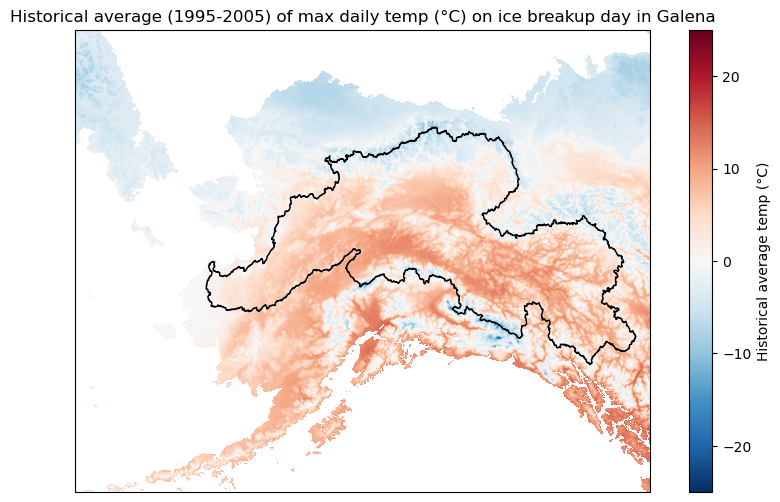

In [136]:
# plot map of the average temperature on breakup day

fig = plt.figure(figsize=(10,6))
cmap = plt.colormaps['RdBu_r']

ax = plt.subplot(1,1,1, projection=ccrs.NorthPolarStereo(central_longitude=-150.0))
ax.set_extent([-170, -132, 55, 72], crs=ccrs.PlateCarree())

cs0 = ax.pcolormesh(lon_2d, lat_2d,
                    hist_mean_temp,
                    cmap=cmap, vmin=-25, vmax=25,
                    shading='auto',
                    transform=ccrs.PlateCarree())

cbar = fig.colorbar(cs0, ax=ax, label='Historical average temp (°C)')
ax.set_title('Historical average (1995-2005) of max daily temp (°C) on ice breakup day in ' + village_name)

# Add shapefile boundary
ax.add_geometries(yukon.geometry, crs=ccrs.PlateCarree(),
                  edgecolor='black', facecolor='none', linewidth=1)

plt.show()

In [137]:
# Get flood year temperature
date_yyyy_np = np.datetime64(village_date)
match_yyyy = np.where(temp_dates == date_yyyy_np)[0][0]
temp_yyyy = temp_daily.isel(time=match_yyyy) - 273.15  # K to °C

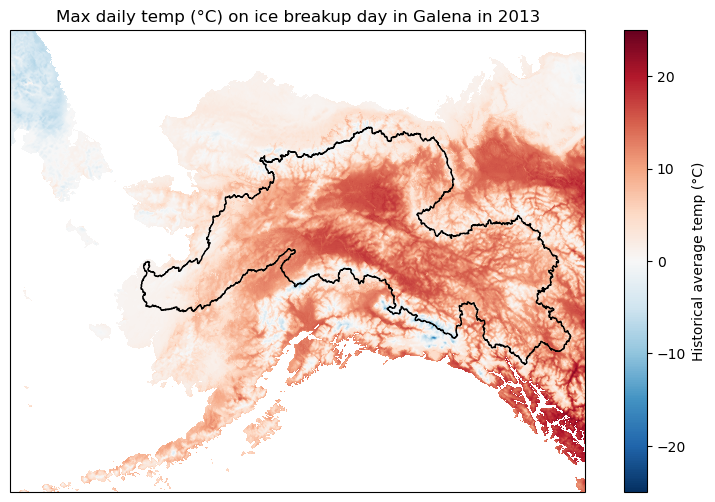

In [138]:
# plot map of temperature on breakup day in flood year

fig = plt.figure(figsize=(10,6))
cmap = plt.colormaps['RdBu_r']

ax = plt.subplot(1,1,1, projection=ccrs.NorthPolarStereo(central_longitude=-150.0))
ax.set_extent([-170, -132, 55, 72], crs=ccrs.PlateCarree())

cs0 = ax.pcolormesh(lon_2d, lat_2d,
                    temp_yyyy,
                    cmap=cmap, vmin=-25, vmax=25,
                    shading='auto',
                    transform=ccrs.PlateCarree())

cbar = fig.colorbar(cs0, ax=ax, label='Historical average temp (°C)')
ax.set_title('Max daily temp (°C) on ice breakup day in ' + village_name + ' in '+str(yy))

# Add shapefile boundary
ax.add_geometries(yukon.geometry, crs=ccrs.PlateCarree(),
                  edgecolor='black', facecolor='none', linewidth=1)

plt.show()

In [139]:
# Compute the anomaly (difference from 1995–2005 mean)
anomaly_yyyy = temp_yyyy.values - hist_mean_temp

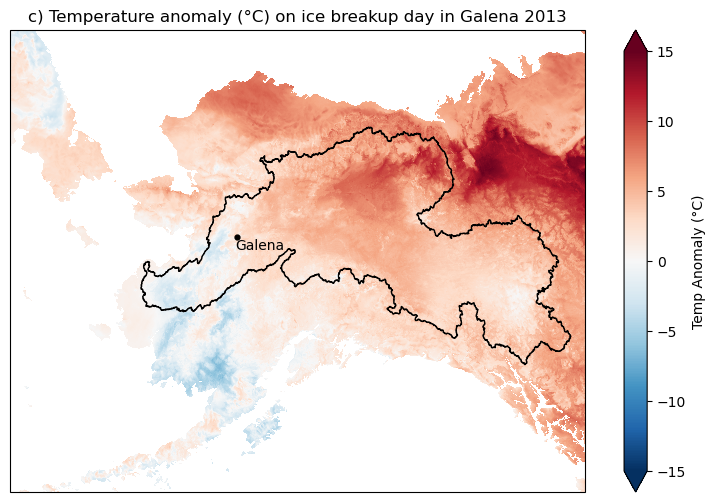

In [140]:
fig = plt.figure(figsize=(10,6))
cmap = plt.colormaps['RdBu_r']

fout = 'temperature_anomaly_on_breakup_'+str(yy)+'.png'

ax = plt.subplot(1,1,1, projection=ccrs.NorthPolarStereo(central_longitude=-150.0))
ax.set_extent([-170, -132, 55, 72], crs=ccrs.PlateCarree())

cs0 = ax.pcolormesh(lon_2d, lat_2d,
                    anomaly_yyyy,
                    cmap=cmap, vmin=-15, vmax=15,
                    shading='auto',
                    transform=ccrs.PlateCarree())

cbar = fig.colorbar(cs0, ax=ax, extend='both',label='Temp Anomaly (°C)')
ax.set_title('c) Temperature anomaly (°C) on ice breakup day in '+village_name+' '+ str(yy))

# Add shapefile boundary
ax.add_geometries(yukon.geometry, crs=ccrs.PlateCarree(),
                  edgecolor='black', facecolor='none', linewidth=1)

# Add point
ax.plot(lon_2d[xloc, yloc].values, lat_2d[xloc, yloc].values, marker='.', color='black', markersize=7, transform=ccrs.PlateCarree())
ax.text(lon_2d[xloc, yloc].values, lat_2d[xloc, yloc].values - 0.5, village_name, color='black', transform=ccrs.PlateCarree())

# save figure
plt.savefig(fout, bbox_inches="tight")
plt.show()


### Plot the distribution of values in Village 1995-2020

In [141]:
# Extract breakup dates for this village
village_breakup = df[(df['Event'] == 'breakup') & (df['COMID'] == comid)].copy()
village_breakup = village_breakup.set_index('Year')

In [142]:
# Get the time array time series
temp_series = temp_daily[:, xloc, yloc]  # shape: (time,)
time_series = temp_series['time'].values

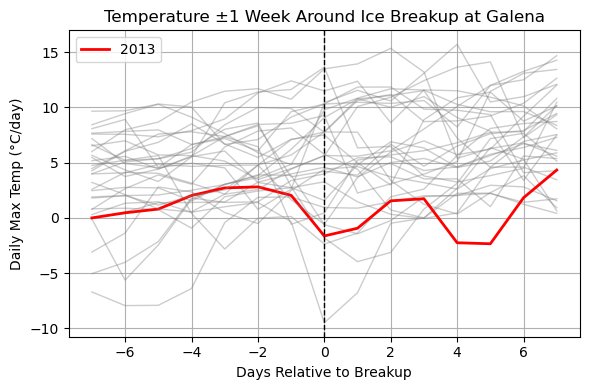

In [143]:
# Plot the raw temperatures before and after breakup at this village
days_range = np.arange(-7, 8)
hydrograph_data = {}

# Loop through breakup years 
for year, row in galena_breakup.iterrows():
    breakup_date = np.datetime64(row['Date'].date())  # strip time to match daily data

    # Get time array from temp_series and convert to date only
    temp_dates = temp_series['time'].values.astype('datetime64[D]')
    matching_idxs = np.where(temp_dates == breakup_date)[0]

    if len(matching_idxs) == 0:
        continue  # Skip if no matching date found
    center_idx = matching_idxs[0]

    # ±7 day window
    idx_range = center_idx + days_range
    if np.any(idx_range < 0) or np.any(idx_range >= len(temp_series)):
        continue

    temps = temp_series[idx_range].values - 273.15  # Convert from K to °C
    hydrograph_data[year] = temps

# Make plot
plt.figure(figsize=(6,4))
for year, slopes in hydrograph_data.items():
    color = 'red' if year == yy else 'gray'
    lw = 2 if year == yy else 1
    alpha = 1.0 if year == yy else 0.4
    label = str(year) if year == yy else None
    plt.plot(days_range, slopes, color=color, linewidth=lw, alpha=alpha, label=label)

plt.axvline(x=0, linestyle='--', color='black', linewidth=1)
plt.title('Temperature ±1 Week Around Ice Breakup at '+village_name)
plt.xlabel('Days Relative to Breakup')
plt.ylabel('Daily Max Temp (°C/day)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

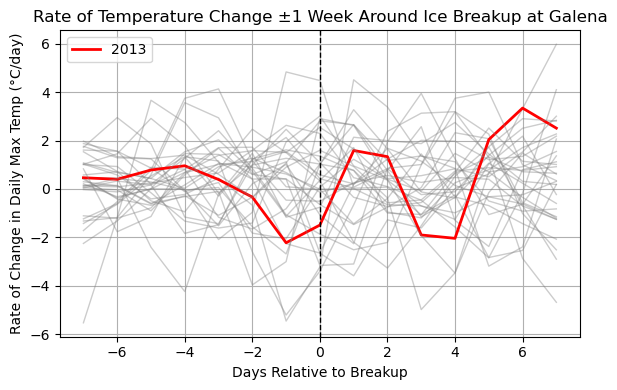

In [144]:
# Plot the rate of temperature change before and after breakup at this village
days_range = np.arange(-7, 8) # number of days before/after breakup to plot
hydrograph_slope_data = {}

for year, row in galena_breakup.iterrows():
    breakup_date = np.datetime64(row['Date'].date())  # strip time to match daily resolution

    # Get time array from temp_series, cast to date only
    temp_dates = temp_series['time'].values.astype('datetime64[D]')

    # Find the index with the same date
    matching_idxs = np.where(temp_dates == breakup_date)[0]

    if len(matching_idxs) == 0:
        continue  # Skip if no matching date found
    center_idx = matching_idxs[0]

    # Extract 15-day window (±7 days)
    idx_range = center_idx + days_range
    if np.any(idx_range < 0) or np.any(idx_range >= len(temp_series)):
        continue  # Skip if out of bounds

    temps = temp_series[idx_range].values - 273.15  # Convert from K to °C
    temp_slope = np.gradient(temps)
    hydrograph_slope_data[year] = temp_slope

# Make Plot
plt.figure(figsize=(6, 4))
for year, slopes in hydrograph_slope_data.items():
    color = 'red' if year == yy else 'gray'
    lw = 2 if year == yy else 1
    alpha = 1.0 if year == yy else 0.4
    label = str(year) if year == yy else None
    plt.plot(days_range, slopes, color=color, linewidth=lw, alpha=alpha, label=label)

plt.axvline(x=0, linestyle='--', color='black', linewidth=1)
plt.title('Rate of Temperature Change ±1 Week Around Ice Breakup at '+village_name)
plt.xlabel('Days Relative to Breakup')
plt.ylabel('Rate of Change in Daily Max Temp (°C/day)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [145]:
# Check if the flood year was significantly different rate of temperature increase compared to other years at this village

temp_slopes = {}  # key = year, value = slope

for year, temps in hydrograph_data.items():
    slope, intercept, r_value, p_value, std_err = linregress(days_range, temps)
    temp_slopes[year] = slope

# get flood year only
slope_yyyy = temp_slopes.get(yy)
other_slopes = [s for y, s in temp_slopes.items() if y != yy]

# get all slopes
slope_df = pd.DataFrame({
    'Year': list(temp_slopes.keys()),
    'Slope (°C/day)': list(temp_slopes.values())
}).sort_values('Year')

#print(slope_df)

# check statistical difference
t_stat, p_val = ttest_1samp(other_slopes, popmean=slope_yyyy)
print('p-value for '+str(yy)+' slope being different from other years:')
print(f"{p_val:.2e}")

p-value for 2013 slope being different from other years:
9.16e-06


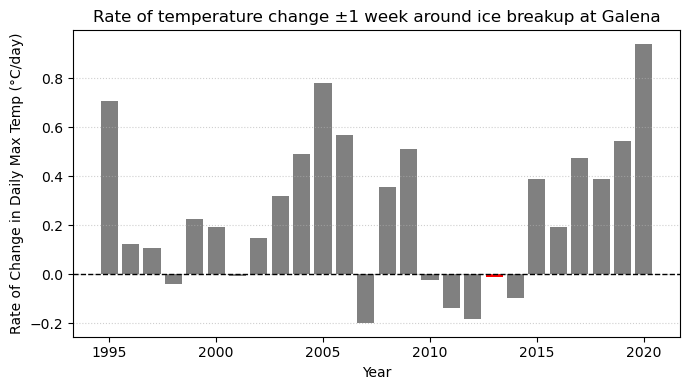

In [146]:
# Plot bar graph for all temperature rates and flood year

# Filter for 1995–2020
filtered_years = [year for year in temp_slopes if 1995 <= year <= 2020]
filtered_years.sort()
filtered_slopes = [temp_slopes[year] for year in filtered_years]
colors = ['red' if year == yy else 'gray' for year in filtered_years]

# Plot slopes
plt.figure(figsize=(7, 4))
plt.bar(filtered_years, filtered_slopes, color=colors)
plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.title('Rate of temperature change ±1 week around ice breakup at '+village_name)
plt.xlabel('Year')
plt.ylabel('Rate of Change in Daily Max Temp (°C/day)')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

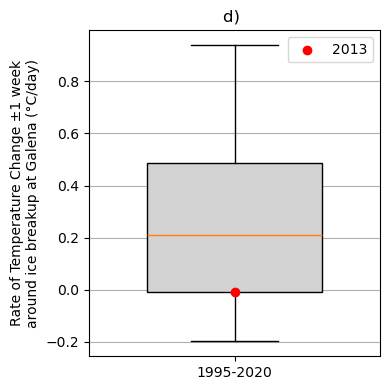

In [147]:
# Plot As Box and Whisker of April Snow Depth distribution
fout = 'temperature_rates_distribution_'+village_name+'_'+str(yy)+'.png'

plt.figure(figsize=(4, 4))
plt.boxplot(filtered_slopes, positions=[0], widths=0.6, patch_artist=True, boxprops=dict(facecolor='lightgray'))
plt.scatter([0], [slope_yyyy], color='red', label=str(yy), zorder=10)
plt.ylabel('Rate of Temperature Change ±1 week\naround ice breakup at '+village_name+' (°C/day)')
plt.title('d) ')
plt.xticks([0], ['1995-2020'])
plt.grid(True, axis='y')
plt.legend()
plt.tight_layout()
plt.savefig(fout, bbox_inches='tight')
plt.show()